In [1]:
%matplotlib ipympl
import MetaArray
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

In [2]:
yaw_angle = 1.6  # degrees, from manipulator calibration
data_path = 'template_data/'
pip_data_path = data_path + 'pipette_data/'
noise_data_path = data_path + 'background_data/'
pip_data_files = sorted(glob.glob(pip_data_path + '*/pipette/*.ma'))
bg_data_files = sorted(glob.glob(pip_data_path + '*/background/*.ma'))

pips = []
for pip, bg in zip(pip_data_files, bg_data_files):
    pips.append({'pip_file': pip, 'bg_file': bg})

noise_data_files = sorted(glob.glob(noise_data_path + '*/*.ma'))

In [3]:
for pip in pips:
    pip_file = pip['pip_file']
    bg_file = pip['bg_file']
    print(f"Processing {pip_file}")
    # load pipette and background data
    pip_ma = MetaArray.MetaArray(file=pip_file)
    bg_ma = MetaArray.MetaArray(file=bg_file)
    # crop to same size
    pip_ma = pip_ma[:len(bg_ma)]
    bg_ma = bg_ma[:len(pip_ma)]
    # subtract background
    pip_img = pip_ma.asarray().astype(float) - bg_ma.asarray().astype(float)
    # rotate
    pip_img = scipy.ndimage.rotate(pip_img, axes=(1, 2), angle=-90-yaw_angle)
    # pip = scipy.ndimage.rotate(pip[110:111], axes=(1, 2), angle=-90-yaw_angle)
    # crop to remove rotation artifacts
    pip_img = pip_img[:, 30:-30, 30:-30]

    if pip_ma._info[0]['name'] == 'Depth':
        z_vals = pip_ma.xvals(0)
    elif 'globalPosition' in pip_ma._info[0]:
        z_vals = pip_ma._info[0]['globalPosition'][:, 2]
    else:
        raise ValueError("Could not find z values")
    z_step_size = np.diff(z_vals).mean()
    pip['pip'] = pip_img
    pip['z_vals'] = z_vals
    pip['z_step_size'] = z_step_size
    print(f"z_step_size: {z_step_size}")


Processing template_data/pipette_data/01/pipette/z_stack_000.ma
z_step_size: 2.900384507089291e-06
Processing template_data/pipette_data/02/pipette/z_stack_000.ma
z_step_size: 2.8492716269764475e-06
Processing template_data/pipette_data/03/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06
Processing template_data/pipette_data/04/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06
Processing template_data/pipette_data/05/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06
Processing template_data/pipette_data/06/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06
Processing template_data/pipette_data/07/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06
Processing template_data/pipette_data/08/pipette/image_000.ma
z_step_size: -1.0000000000001327e-06


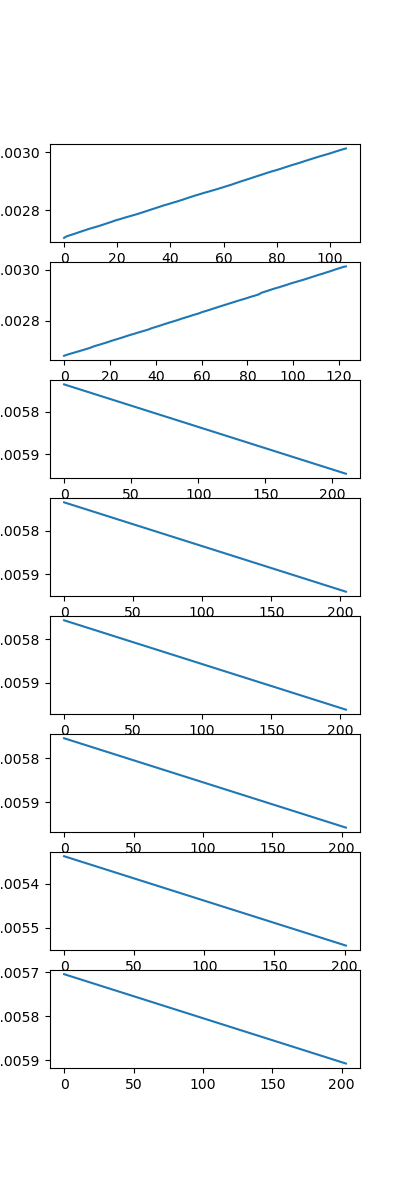

In [4]:
fig, ax = plt.subplots(len(pips), 1, figsize=(4, 12))
for i, pip in enumerate(pips):
    ax[i].plot(pip['z_vals'])


interactive(children=(IntSlider(value=42, description='index', max=106), Output()), _dom_classes=('widget-inte…

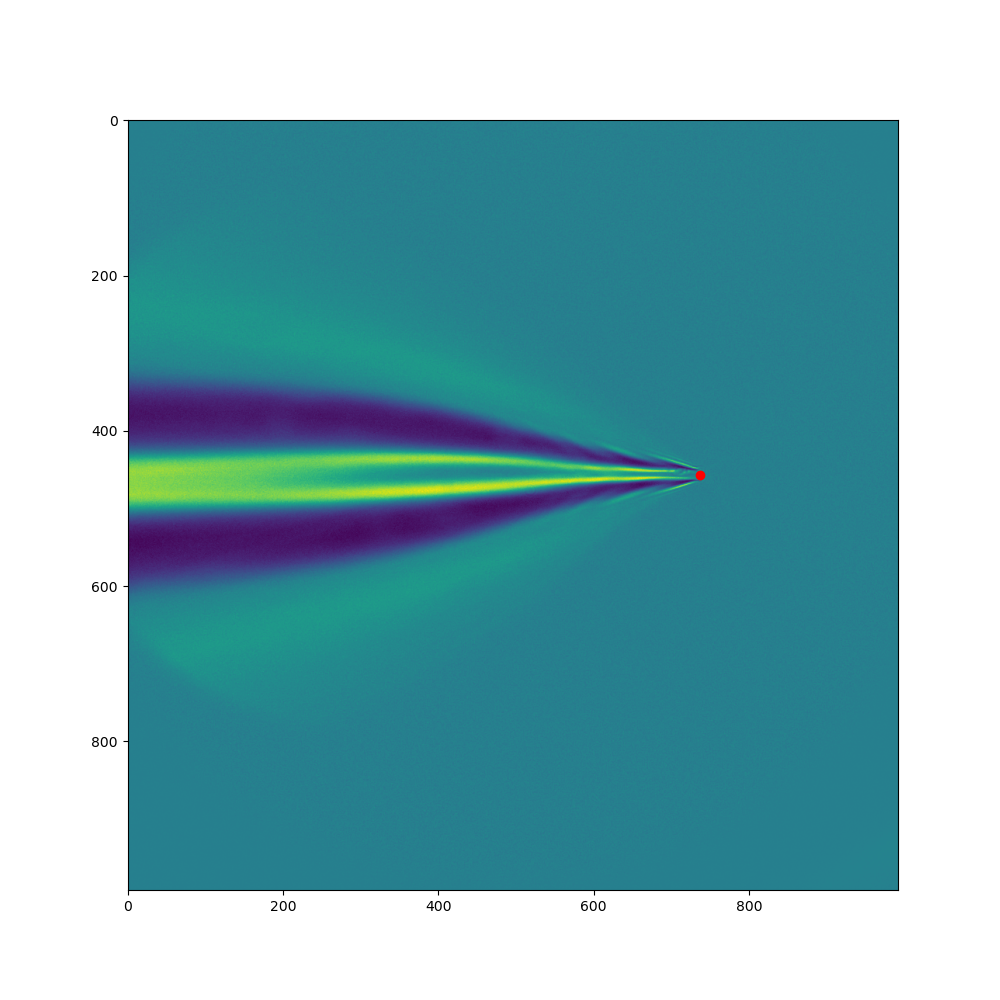

In [5]:
import ipywidgets

# manually extracted tip positions
tips = {
    'template_data/pipette_data/01/pipette/z_stack_000.ma': (42, 457, 737),  # 0
    'template_data/pipette_data/02/pipette/z_stack_000.ma': (65, 942, 1270), # 1
    'template_data/pipette_data/03/pipette/image_000.ma': (107, 478, 712),   # 2
    'template_data/pipette_data/04/pipette/image_000.ma': (155, 529, 691),   # 3
    'template_data/pipette_data/05/pipette/image_000.ma': (153, 572, 688),   # 4
    'template_data/pipette_data/06/pipette/image_000.ma': (154, 479, 681),   # 5
    'template_data/pipette_data/07/pipette/image_000.ma': (153, 480, 665),         # 6
    'template_data/pipette_data/08/pipette/image_000.ma': (154, 480, 661),         # 7
}
for pip in pips:
    pip['tip_pos'] = tips[pip['pip_file']]

# which template to display below
i = 0

fig, ax = plt.subplots(figsize=(10, 10))
tip = pips[i]['tip_pos']
img = pips[i]['pip']
imshw = ax.imshow(img[tip[0]])
ax.scatter(tip[2], tip[1], color='r')
# spacing = 25
# ax.set_xticks(range(0, img.shape[2], spacing));
# ax.set_yticks(range(0, img.shape[1], spacing));


def update(index=tip[0]):
    imshw.set_data(img[index])
    fig.canvas.draw_idle()
    
ipywidgets.interact(update, index=(0, img.shape[0]-1, 1));

Processing template_data/pipette_data/01/pipette/z_stack_000.ma
Processing template_data/pipette_data/02/pipette/z_stack_000.ma
Processing template_data/pipette_data/03/pipette/image_000.ma
Processing template_data/pipette_data/04/pipette/image_000.ma
Processing template_data/pipette_data/05/pipette/image_000.ma
Processing template_data/pipette_data/06/pipette/image_000.ma
Processing template_data/pipette_data/07/pipette/image_000.ma
Processing template_data/pipette_data/08/pipette/image_000.ma


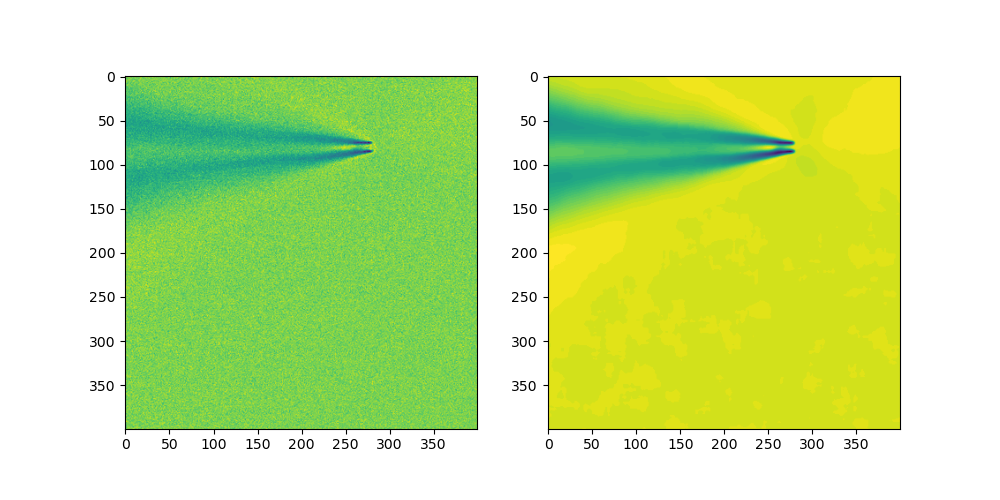

In [6]:
# remove noise

import cv2 as cv

def denoise(img):
    img_min = img.min()
    img_max = img.max()
    scale = 255 / (img_max - img_min)
    normed_img = (img - img_min) * scale
    gauss_filtered = scipy.ndimage.gaussian_filter(normed_img, (1, 1, 1))
    byte_img = np.clip(gauss_filtered, 0, 255).astype(np.uint8)

    denoised = []
    for i in range(byte_img.shape[0]):
        radius = min(i, byte_img.shape[0] - i - 1, 2)
        denoised.append(
            cv.fastNlMeansDenoisingMulti(
                byte_img, i, 
                temporalWindowSize=radius*2+1, 
                h=7, 
                templateWindowSize=7, 
                searchWindowSize=21)
        )
    return np.stack(denoised)


for pip in pips:
    print(f"Processing {pip['pip_file']}")
    pip['denoised'] = denoise(pip['pip'])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
selected = 5
ax[0].imshow(pips[selected]['pip'][155, 400:800, 400:800])
ax[1].imshow(pips[selected]['denoised'][155, 400:800, 400:800])


In [7]:
for pip in pips:
    # apply mask to fade out
    def gradient(row, col):
        tip = tips[pip['pip_file']]
        maxr = min(tip[1], tip[2])
        r = ((row - tip[1])**2 + (col - tip[2])**2) ** 0.5
        return np.clip((maxr - r) / (4 * maxr), 0, 1)
            
    mask = np.fromfunction(gradient, shape=pip['pip'].shape[1:])
    pip['mask'] = mask


In [8]:
for pip in pips:
    tip_pos = list(tips[pip['pip_file']])
    bg = np.median(pip['denoised'])
    templ = pip['mask'][np.newaxis, ...] * (pip['denoised'] - bg)
    r = min(tip_pos[1], tip_pos[2])
    # crop right/bottom
    templ = templ[:tip_pos[0]+r, :tip_pos[1]+r]
    # crop top
    if tip_pos[1] > r:
        dif = tip_pos[1] - r
        templ = templ[:, dif:, :]
        tip_pos[1] -= dif
    # crop left
    if tip_pos[2] > r:
        dif = tip_pos[2] - r
        templ = templ[:, :, dif:]
        tip_pos[2] -= dif

    # normalize and convert
    templ /= np.abs(templ).max()
    templ = templ.astype('float32')
    # templ -= templ.min()
    # templ *= 255. / templ.max()
    # templ = templ.astype('ubyte')
    pip['template'] = templ
    pip['template_pos'] = np.array(tip_pos)
    


In [16]:
# save templates
for i,pip in enumerate(pips):
    template = pip['template']
    template_pos = pip['template_pos']
    # z_um = 1e6 * (template_pos[0] - np.arange(template.shape[0])) * pip['z_step_size']
    pip['z_um'] = 1e6 * (pip['z_vals'] - pip['z_vals'][template_pos[0]])
    np.savez_compressed(
        data_path + f'template_{i:03d}.npz',
        image_data=template,
        pipette_pos=template_pos[1:],
        z_um=pip['z_um'],
    ) 

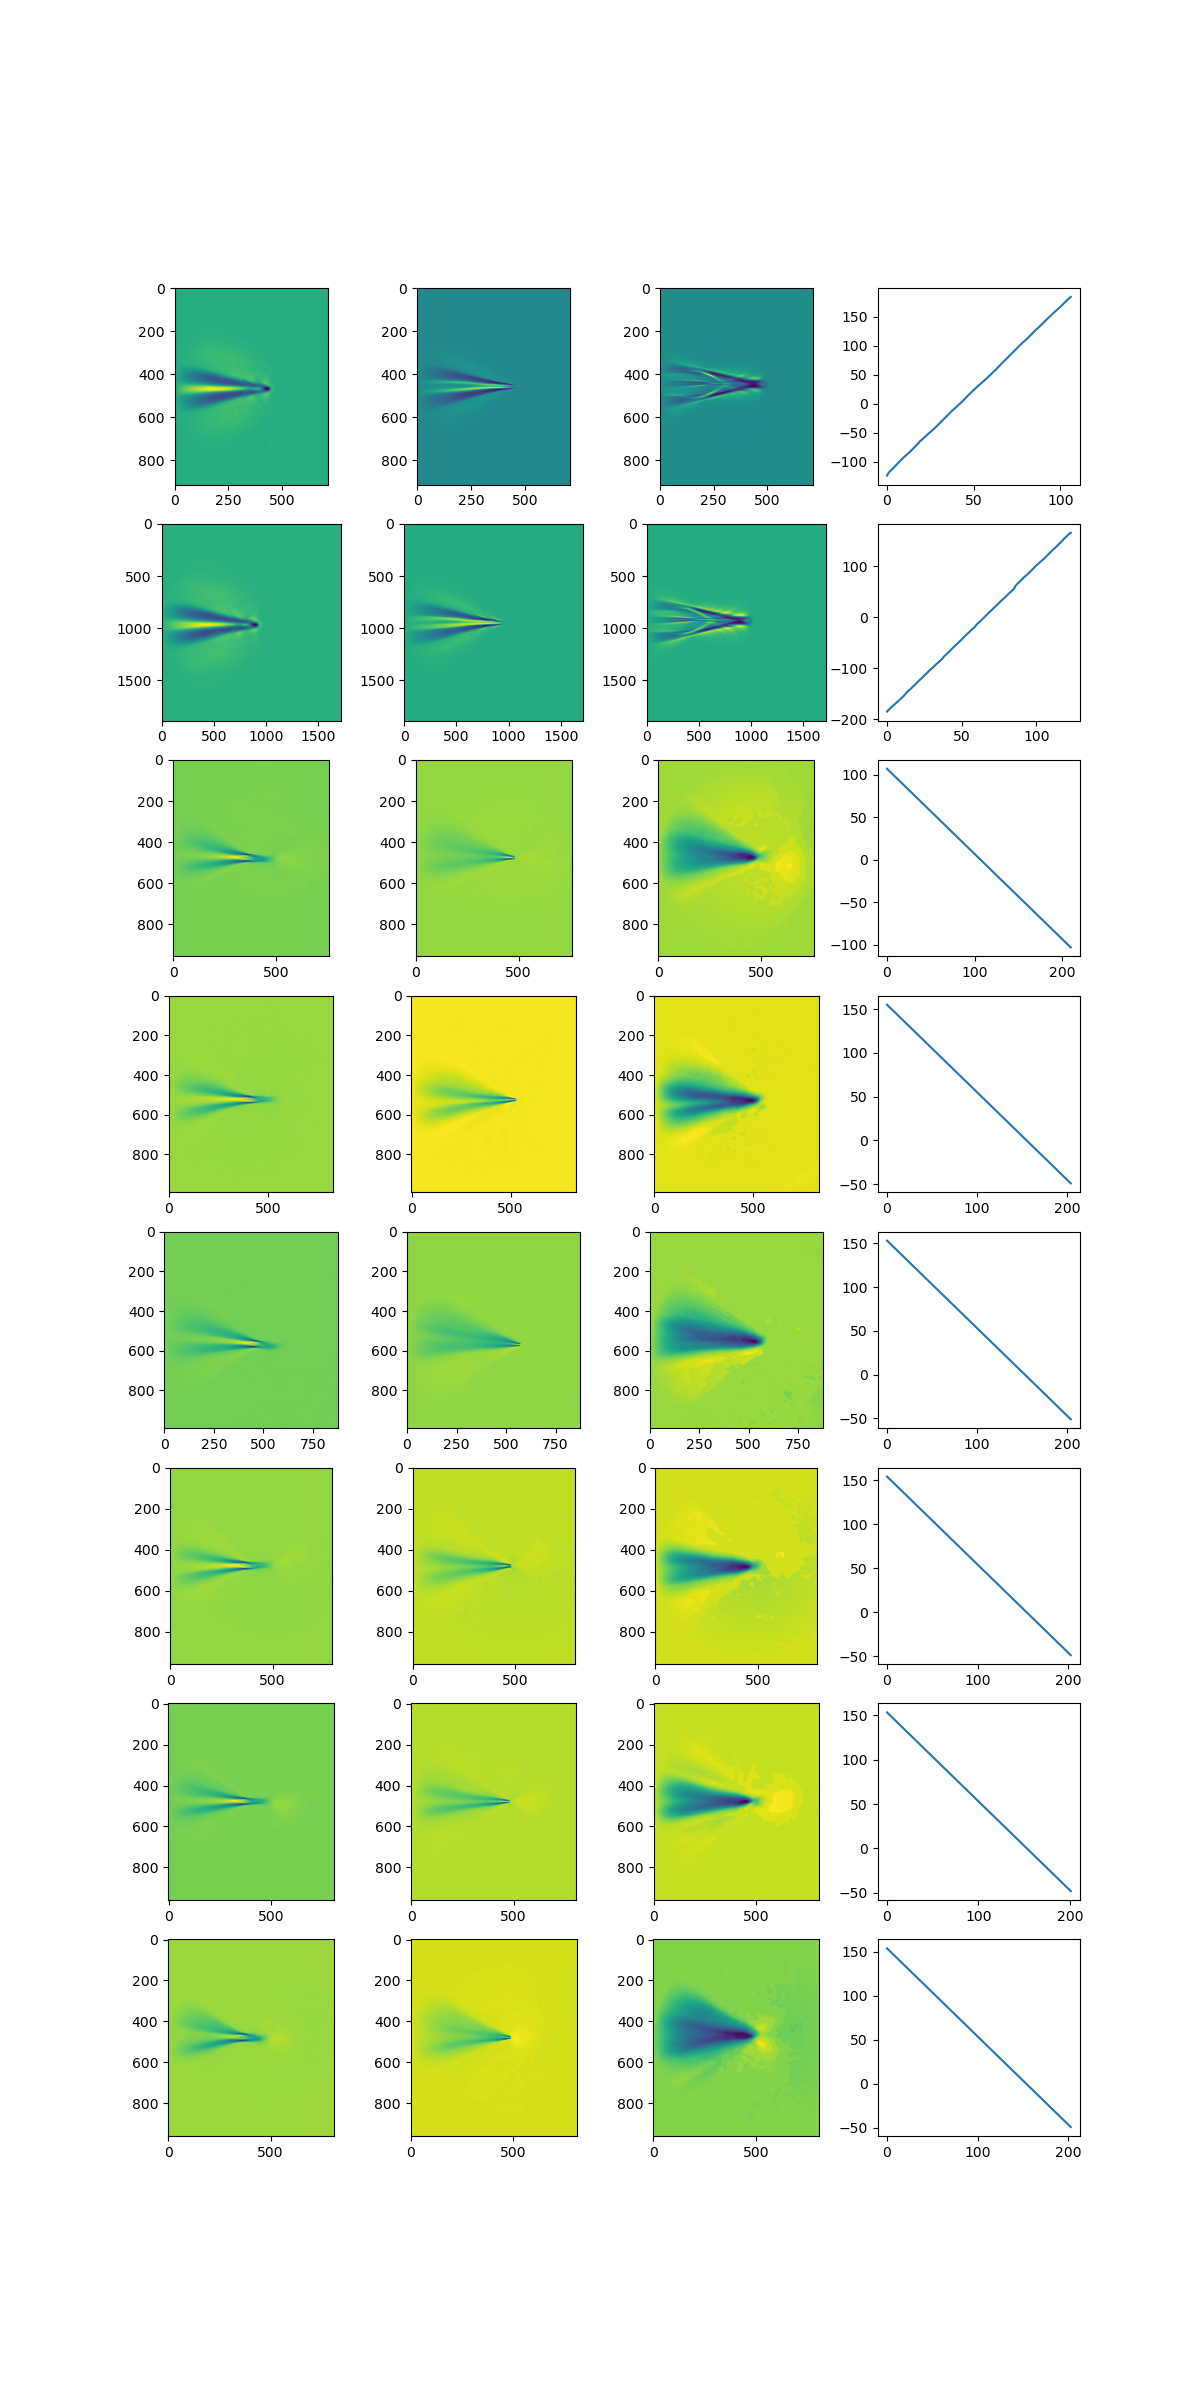

In [17]:
fig, ax = plt.subplots(len(pips), 4, figsize=(12, 3*len(pips)))
for i, pip in enumerate(pips):
    for j,z in enumerate([-20, 0, 20]):
        ax[i, j].imshow(pip['template'][pip['template_pos'][0] + z])
    # plot z values
    ax[i, 3].plot(pip['z_um'])

